In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
train = pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [22]:
# حذف الأعمدة غير المهمة
train = train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [23]:
# تعويض Age حسب Pclass
train['Age'] = train.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.mean())
)

# تعويض Embarked (فقط 2 مفقود)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

train.isnull().sum()

/tmp/ipython-input-783/1524284811.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [24]:
# One-hot encoding
train = pd.get_dummies(train, columns=['Sex', 'Embarked'], drop_first=True)

train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [26]:
from sklearn.preprocessing import StandardScaler

# تحويل bool لـ int
bool_cols = ['Sex_male', 'Embarked_Q', 'Embarked_S']
train[bool_cols] = train[bool_cols].astype(int)

# Scaling
scaler = StandardScaler()
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
train[num_cols] = scaler.fit_transform(train[num_cols])

train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.552360,0.432793,-0.473674,-0.502445,1,0,1
1,1,1,0.659475,0.432793,-0.473674,0.786845,0,0,0
2,1,3,-0.249401,-0.474545,-0.473674,-0.488854,0,0,1
3,1,1,0.432256,0.432793,-0.473674,0.420730,0,0,1
4,0,3,0.432256,-0.474545,-0.473674,-0.486337,1,0,1


In [27]:
from sklearn.model_selection import train_test_split

X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((712, 8), (179, 8))

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_results.append((k, acc))

knn_results

[(1, 0.7262569832402235),
 (3, 0.7988826815642458),
 (5, 0.8044692737430168),
 (7, 0.8044692737430168),
 (9, 0.8100558659217877),
 (11, 0.7877094972067039),
 (15, 0.7877094972067039),
 (21, 0.776536312849162)]

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=4)
dt.fit(X_train, y_train)

dt_acc = dt.score(X_test, y_test)
dt_acc

0.7932960893854749

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

k_best = max(knn_results, key=lambda x: x[1])[0]
knn_best = KNeighborsClassifier(n_neighbors=k_best)
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)

print("Best K:", k_best)
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nKNN Report:\n", classification_report(y_test, y_pred_knn))

Best K: 9
KNN Confusion Matrix:
 [[98 12]
 [22 47]]

KNN Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [31]:
y_pred_dt = dt.predict(X_test)

print("DT Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nDT Report:\n", classification_report(y_test, y_pred_dt))

DT Confusion Matrix:
 [[104   6]
 [ 31  38]]

DT Report:
               precision    recall  f1-score   support

           0       0.77      0.95      0.85       110
           1       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



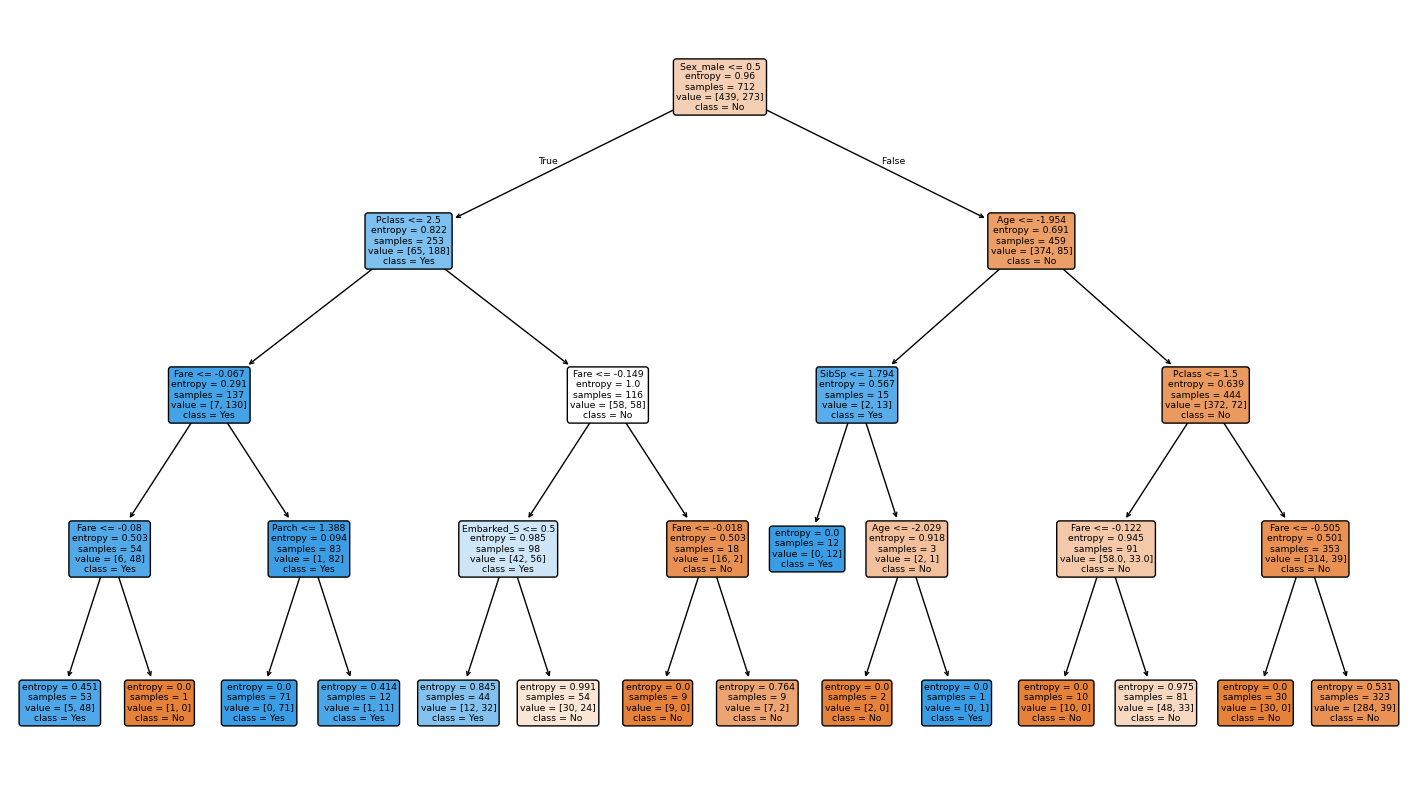

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(dt, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.show()